<a href="https://colab.research.google.com/github/jenny4890/deepLearning/blob/main/RNN_structure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import torch
import torch.nn as nn

#pytorch programming paradim : pytorch 뉴럴네트웍 안에는 오직 weight들만 있게 한다.
#그래서 def get_hidden(self): zero로 프로그래밍한다.
class Myrnn(nn.Module):
  def __init__(self, inputsize, hiddensize, outputsize):
    super().__init__()
    self.hiddensize = hiddensize #hiddenstate
    self.i2h = nn.Linear(inputsize+hiddensize, hiddensize) # input to hiddenstate
    self.h2o = nn.Linear(hiddensize, outputsize) # hiddenstate to output

  def forward(self, input, hidden):
    combine = torch.cat((input,hidden),1)
    hidden = torch.tanh(self.i2h(combine))
    output = self.h2o(hidden)
    return output, hidden

  def get_hidden(self):
    return torch.zeros(1, self.hiddensize) # 1은 batch size 1이다.

rnnmodel = Myrnn(inputsize=4, hiddensize=4, outputsize=2)# output = positive/negative
hidden= rnnmodel.get_hidden() # hidden model 초기화
vocab = {
    "the": 0,
    "food": 1,
    "is": 2,
    "good": 3
}

#the food is good
words = ["the","food","is","good"]
embedding = nn.Embedding(4,4) # parameters: word수, word를 몇차원으로 표현하느냐?
for word in words:
  idx = torch.tensor([vocab[word]])
  x = embedding(idx)
  output, hidden = rnnmodel(x, hidden)

print(output)
print(hidden)

'''
output0, hidden = rnnmodel(input0, hidden)#the
output1, hidden = rnnmodel(input1, hidden)# food
output2, hidden = rnnmodel(input2, hidden)# is
output3, hidden = rnnmodel(input3, hidden)# good
'''

tensor([[ 0.4761, -0.6020]], grad_fn=<AddmmBackward0>)
tensor([[ 0.1051, -0.3220,  0.4225, -0.6683]], grad_fn=<TanhBackward0>)


'  \noutput0, hidden = rnnmodel(input0, hidden)#the \noutput1, hidden = rnnmodel(input1, hidden)# food\noutput2, hidden = rnnmodel(input2, hidden)# is\noutput3, hidden = rnnmodel(input3, hidden)# good\n'

 hidden state to OOUTPUT [ | ]
 nn.Linear i2h ([ | | | ])

 input to hidden state [ | | | ]
    tanh   (                    )
nn.Linear ( [ | | | ][ | | | ] )

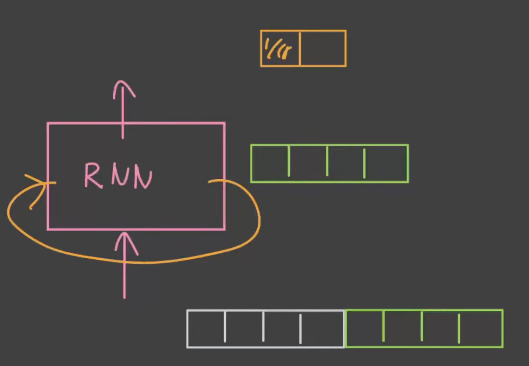